In [29]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
import kagglehub

# Importei um dataset simples do kaggle para testar este modelo
    Mesmo com dados diferentes useis as tecnicas da aula

In [30]:
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

df = pd.read_csv(f"{path}/Mall_Customers.csv")

In [31]:
df.head()
# Gender é o sexo da pessoa | Age é idade |	Annual Income (k$)	salario anual | Spending Score (1-100) frequencia de gastos

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
df.shape

(200, 5)

In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# separo as features que serao utilizadas pelo modelo

In [ ]:
xnorm = scale(X)
# normalizo as features para o modelo se adaptar melhor
inert=[]
for i in range(1,11):
    model = KMeans(n_clusters=i, n_init=20)
    model = model.fit(xnorm)
    inert.append(model.inertia_)
    # adiciona a lista o erro quadratico do teste
    #testa o modelo com 10 Ks diferentes oapara achar o melhor resultad, o n_init define quantas vezes o algoritmo roda com centroides iniciais, ou seja, ficando com o resultado de menor erro entre essas tentativas

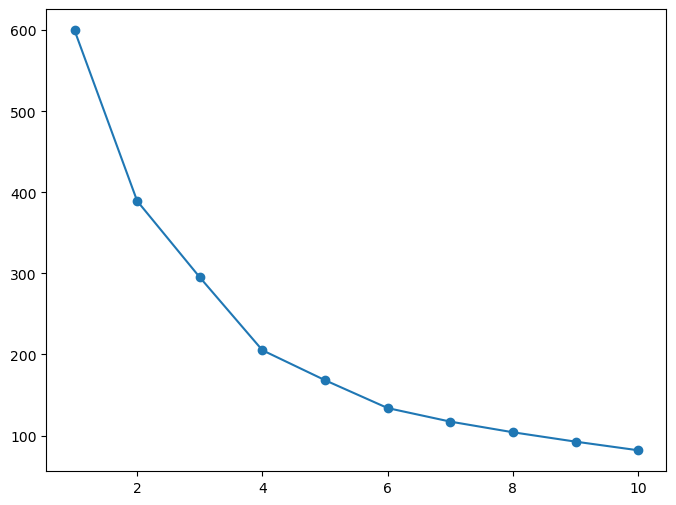

In [34]:
plt.figure(figsize=(8,6))
plt.plot(range(1,11), inert, marker = "o")
plt.show()

# O modelo com 4 clusters é a melhor opção pois é onde a reta suaviza e começa a ir mais reta. O grafico acima mostra o inert que é o metrica de erro quadratico, nao e pego o numero de 10 que tem menor pois é padrao que com mais clusters ele diminui os erros.

In [52]:
model = KMeans(n_clusters=4, n_init=20)
model = model.fit(xnorm)

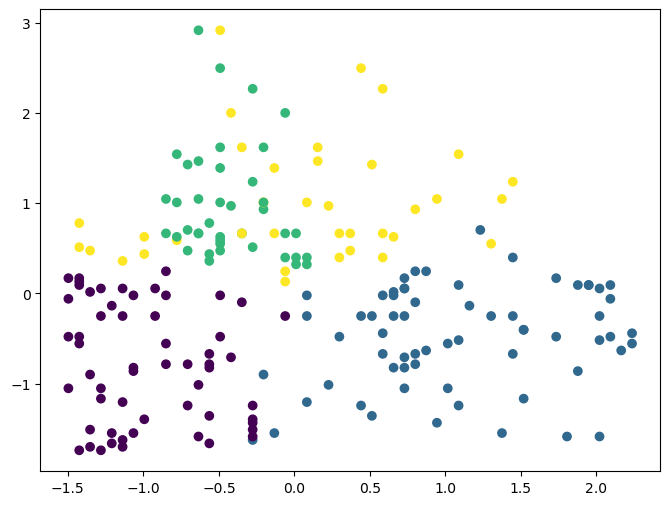

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(xnorm[:,0],xnorm[:,1],c=model.labels_.astype(float))
plt.savefig("clustering_kmeans.png")
plt.show()

In [ ]:
model2 = KMeans(n_clusters=2, n_init=20)
model2 = model2.fit(xnorm)
# compara o cluster 2 e 4

In [ ]:
print("Centroides K=2:", model2.cluster_centers_)
print("Centroides K=4:", model.cluster_centers_)
# compara resultados entre 2 e 4 clusters

Centroides K=2: [[ 0.70892251 -0.00247545 -0.69939115]
 [-0.75277339  0.00262858  0.74265245]]
Centroides K=4: [[-0.96249203 -0.78476346  0.39202966]
 [ 1.08616125 -0.49056525 -0.39717443]
 [-0.42880597  0.97484722  1.21608539]
 [ 0.03720536  0.99011499 -1.18875705]]
